In [2]:
%reload_ext autoreload
%autoreload 1

# M5 Forecast

## Imports

In [5]:
import os
import time
import numpy as np
import multiprocessing
import pandas as pd
from pathlib import Path

id_col = "id"
time_col = "date"
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

PATH_INPUT = Path("data/m5/datasets")
N_JOBS = multiprocessing.cpu_count()

HORIZON = 28  # How many days into the future to predict
VAL_DAYS = 0  # How many days of data to hold-out for validatioin (set to 0 for live)

if not PATH_INPUT.exists():
    raise FileNotFoundError("Please download the M5 dataset first by executing `src/generate_data.py`")
    
os.environ["NIXTLA_ID_AS_COL"] = '1'
start_time = time.time()

# Helper Functions

In [6]:
start_time = time.time()

from typing import List
import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean, SeasonalRollingMean
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mse, mase, mape, mae, smape
from utilsforecast.plotting import plot_series
from utilsforecast.preprocessing import fill_gaps
from src.process import *

def is_first_or_fifteenth(dates):
    """Date is the 1st or 15th of the month"""
    return dates.day.isin([1, 15])

def even_day(dates):
    """Day of month is even"""
    return dates.day % 2 == 0

def month_start_or_end(dates):
    """Date is month start or month end"""
    return dates.is_month_start | dates.is_month_end

def is_monday(dates):
    """Date is monday"""
    return dates.dayofweek == 0

def downcast_id_col(df: pd.DataFrame, 
                    df_ids: pd.DataFrame, 
                    id_col: str = id_col):
    """Downcast df[id_col] to integer.
    """
    df[id_col] = df[id_col].map(df_ids.set_index("id")["idx"].to_dict())

def is_business_day(dates):
    """Date is a business day (Monday to Friday)"""
    return dates.dt.dayofweek < 5  # Monday=0, Sunday=6

def is_quarter_start(dates):
    """Date is quarter start"""
    return dates.dt.is_quarter_start

def even_day(dates):
    """Day of month is even"""
    return dates.dt.day % 2 == 0

def month_start_or_end(dates):
    """Date is month start or month end"""
    return dates.dt.is_month_start | dates.dt.is_month_end

def is_monday(dates):
    """Date is Monday"""
    return dates.dt.dayofweek == 0

def is_weekend(dates):
    """Date is on a weekend (Saturday or Sunday)"""
    return dates.dt.dayofweek >= 5

def is_week_start(dates):
    """Date is the start of the week (Monday)"""
    return dates.dt.dayofweek == 0

def is_week_end(dates):
    """Date is the end of the week (Sunday)"""
    return dates.dt.dayofweek == 6

def is_year_start_or_end(dates):
    """Date is year start or year end"""
    return dates.dt.is_year_start | dates.dt.is_year_end

def is_leap_year(dates):
    """Date is in a leap year"""
    return dates.dt.is_leap_year

def days_until_month_end(dates):
    """Number of days until the end of the month"""
    month_end = dates + pd.offsets.MonthEnd(0)
    return (month_end - dates).dt.days

def is_fiscal_year_end(dates, month=12):
    """Date is the end of the fiscal year
    Args:
        dates (pd.Series): Series of datetime objects.
        month (int): Month considered as the fiscal year-end.
    """
    return (dates.dt.month == month) & dates.dt.is_month_end

def day_of_quarter(dates):
    """Day number within the quarter"""
    quarter_start = dates.dt.to_period('Q').start_time
    return (dates - quarter_start).dt.days + 1

def week_of_month(dates):
    """Week number within the month"""
    return ((dates.dt.day - 1) // 7) + 1

def is_special_date(dates, special_dates):
    """Date matches any in a list of special dates
    Args:
        dates (pd.Series): Series of datetime objects.
        special_dates (list or set): Special dates to check against.
    """
    special_dates = pd.to_datetime(special_dates)
    return dates.isin(special_dates)


def evaluate_cross_validation(df: pd.DataFrame,
                              metric: callable, 
                              id_col: str = 'unique_id',
                              time_col: str = "ds",
                             ) -> pd.DataFrame:
    """Evaluate cross-validation results.
    """
    models = df.drop(columns=[id_col, 'ds', 'cutoff', 'y']).columns.tolist()
    evals = []
    # Calculate loss for every unique_id and cutoff.    
    for cutoff in df['cutoff'].unique():
        eval_ = evaluate(df[df['cutoff'] == cutoff],
                         metrics=[metric],
                         models=models,
                         id_col=id_col,
                         time_col=time_col)
        evals.append(eval_)
    evals = pd.concat(evals)
    evals = evals.groupby(id_col).mean(numeric_only=True) # Averages the error metrics for all cutoffs for every combination of model and unique_id
    evals['best_model'] = evals.idxmin(axis=1)
    return evals


def get_best_model_forecast(forecasts_df: pd.DataFrame,
                            evaluation_df: pd.DataFrame, 
                            id_col: str = "unique_id") -> pd.DataFrame:
    """Create Production Forecast DataFrame.

    returns: df Dataframe with columns:
        id_col, ds, best_model, forecast.
    """
    df = forecasts_df.set_index([id_col, "ds"]).stack().to_frame().reset_index(level=2)
    df.columns = ['model', 'best_model_forecast']
    df = df.join(evaluation_df[['best_model']])

    df = df[df["best_model"] == df["model"]].reset_index().drop("model", axis=1)
    return df

# Load Inputs

In [73]:
df = pd.read_parquet("data/train.snap.parquet")

# Model

In [8]:
# Future Covariates
X_cols = ['sell_price', 'id', 'date', 'event_name_1', 'event_type_1',
          'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

In [72]:
df["date"].nunique()

400

# Statistical Forecast
This is just a quick exploration, implement `Naive` forecast to set a benchmark for performance. There are too many time-series for the statistical models to use as a starting point.

- [statsforecast - nixtla](https://)
- [naive-methods](https://otexts.com/fpp3/simple-methods.html)
- [complex-exponential smoothing](https://onlinelibrary.wiley.com/doi/full/10.1002/nav.22074)

In [12]:
from statsforecast.models import (
    Naive, 
    WindowAverage,
    SeasonalNaive,

    # Statistical Models
    AutoARIMA, AutoETS, AutoCES,
    
    # Itermittent Demand Models
    CrostonOptimized,
    CrostonSBA,
    CrostonClassic as Croston,
    # IMAPA,
)
from statsforecast.models import IMAPA
from statsforecast import StatsForecast


K = 50   # How to choose seasonality for daily data

model_list = [Naive(),
              WindowAverage(window_size=7 * 1, alias="1WeekMA"),
              WindowAverage(window_size=7 * 2, alias="2WeekMA"),
              WindowAverage(window_size=7 * 4, alias="4WeekMA"),

              # Itermittment Demand Optimized Models
              Croston(),
              CrostonOptimized(),
              CrostonSBA(),

              # # IMAPA(),
              # These take far too long
              # AutoCES(season_length=K),
              # AutoETS(season_length=K),
              AutoETS(season_length=7, model='ZNA'),
             ]

sf = StatsForecast(models=model_list, freq="D", n_jobs=N_JOBS)

# Cross-Validation

In [13]:
%%time

CV_WINDOWS = 3

stat_cv = sf.cross_validation(h=HORIZON,
                              n_windows=CV_WINDOWS,
                              df=df,
                              id_col=id_col, time_col=time_col
                             )

stat_cv.tail()

CPU times: total: 3.16 s
Wall time: 4min 2s


,id,date,cutoff,y,Naive,1WeekMA,2WeekMA,4WeekMA,CrostonClassic,CrostonOptimized,CrostonSBA,AutoETS
2561155,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,2016-04-24,0.0,0.0,0.0,0.0,0.0,0.105593,0.099641,0.100313,0.043076
2561156,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,2016-04-24,0.0,0.0,0.0,0.0,0.0,0.105593,0.099641,0.100313,0.061426
2561157,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,2016-04-24,0.0,0.0,0.0,0.0,0.0,0.105593,0.099641,0.100313,0.061661
2561158,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,2016-04-24,0.0,0.0,0.0,0.0,0.0,0.105593,0.099641,0.100313,0.174706
2561159,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-22,2016-04-24,0.0,0.0,0.0,0.0,0.0,0.105593,0.099641,0.100313,0.189599


In [17]:
%%time

sf.fit(df[df["item_id"].isin(df.item_id.sample(100))], id_col=id_col, time_col=time_col)
sf.fit(df, id_col=id_col, time_col=time_col)
       # df[["id", "date", "y"]].rename(columns={"id": "unique_id", "date": "ds"}))
stat_preds = sf.predict(HORIZON)
stat_preds

CPU times: total: 22 s
Wall time: 2min 10s


,id,date,Naive,1WeekMA,2WeekMA,4WeekMA,CrostonClassic,CrostonOptimized,CrostonSBA,AutoETS
0,FOODS_1_001_CA_1_evaluation,2016-05-23,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.797399
1,FOODS_1_001_CA_1_evaluation,2016-05-24,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.761147
2,FOODS_1_001_CA_1_evaluation,2016-05-25,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.746669
3,FOODS_1_001_CA_1_evaluation,2016-05-26,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.675291
4,FOODS_1_001_CA_1_evaluation,2016-05-27,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.884552
...,...,...,...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-15,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.037924
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-16,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.055271
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-17,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.070655
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-18,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.177857


In [18]:
stat_model_list = [str(m) for m in sf.models]
stat_model_list

['Naive',
 '1WeekMA',
 '2WeekMA',
 '4WeekMA',
 'CrostonClassic',
 'CrostonOptimized',
 'CrostonSBA',
 'AutoETS']

In [22]:
stat_preds

,id,date,Naive,1WeekMA,2WeekMA,4WeekMA,CrostonClassic,CrostonOptimized,CrostonSBA,AutoETS
0,FOODS_1_001_CA_1_evaluation,2016-05-23,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.797399
1,FOODS_1_001_CA_1_evaluation,2016-05-24,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.761147
2,FOODS_1_001_CA_1_evaluation,2016-05-25,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.746669
3,FOODS_1_001_CA_1_evaluation,2016-05-26,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.675291
4,FOODS_1_001_CA_1_evaluation,2016-05-27,0.0,0.142857,0.642857,0.821429,0.898247,0.884668,0.853334,0.884552
...,...,...,...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-15,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.037924
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-16,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.055271
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-17,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.070655
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-06-18,0.0,0.000000,0.071429,0.071429,0.076139,0.063026,0.072332,0.177857


In [23]:

stat_preds.to_parquet("data/stat_baseline.snap.parquet")

In [ ]:
TRAIN_START = 1
TRAIN_END = 1941

TEST_START = 1942
TEST_END = 1969
TEST_DAYS = [f"d_{x}" for x in range(TEST_START, TEST_END + 1)]

from datasetsforecast.m5 import M5Evaluation
truth = pd.read_csv(PATH_INPUT / "sales_test_evaluation.csv")
truth["id"] = truth["item_id"].astype(str) + "_" + truth["store_id"].astype(str) + "_evaluation"

# def make_submission(preds: pd.DataFrame,
#                     h: int) -> pd.DataFrame:
#     wide = preds.pivot_table(index='id',
#                              columns='date',
#                              observed=True)
#     wide.columns = [f'F{i+1}' for i in range(h)]
#     wide.columns.name = None
#     wide.index.name = 'id'
#     return wide


In [25]:
stat_models = sf.models

for model in stat_model_list:
    preds_long = stat_preds[["id", "date", str(model)]]
    df_sub = make_submission(preds_long, HORIZON)
    df_sub = truth[id_cols].merge(df_sub, on=["id"])
    model_score = M5Evaluation.evaluate("data", df_sub)
    model_score_avg = model_score["wrmsse"].mean()
    logger.info(f"""{model} scored: {model_score_avg:.3f}""")


2025-08-24 12:41:23.867 | INFO     | __main__:<module>:9 - Naive scored: 1.752
2025-08-24 12:41:33.695 | INFO     | __main__:<module>:9 - 1WeekMA scored: 0.955
2025-08-24 12:41:43.926 | INFO     | __main__:<module>:9 - 2WeekMA scored: 0.963
2025-08-24 12:41:53.757 | INFO     | __main__:<module>:9 - 4WeekMA scored: 0.946
2025-08-24 12:42:02.888 | INFO     | __main__:<module>:9 - CrostonClassic scored: 0.955
2025-08-24 12:42:12.617 | INFO     | __main__:<module>:9 - CrostonOptimized scored: 0.968
2025-08-24 12:42:21.835 | INFO     | __main__:<module>:9 - CrostonSBA scored: 0.960
2025-08-24 12:42:30.898 | INFO     | __main__:<module>:9 - AutoETS scored: 0.678


In [64]:
%%time

from tqdm.auto import tqdm

stat_models = sf.models

stat_results = []

pbar = tqdm(sf.models)
for model in pbar:
    model = str(model)
    preds_long = stat_preds[["id", "date", model]].copy()
    preds_long[model] = preds_long[model].round(0).clip(0)
    df_sub = make_submission(preds_long, HORIZON)
    df_sub = truth[id_cols].merge(df_sub, on=["id"])
    model_score = M5Evaluation.evaluate("data", df_sub)
    model_score["model"] = model
    model_score_avg = model_score["wrmsse"].mean()
    stat_results.append(model_score)
    pbar.set_postfix({"{model} wrmsse": model_score_avg})

  0%|          | 0/8 [00:00<?, ?it/s]

CPU times: total: 1min 16s
Wall time: 1min 16s


In [65]:
dfresults_stats = pd.concat(stat_results)
dfresults_stats

,wrmsse,model
Total,1.752010,Naive
Level1,1.966796,Naive
Level2,1.904404,Naive
Level3,1.879622,Naive
Level4,1.946932,Naive
...,...,...
Level8,0.736065,AutoETS
Level9,0.834301,AutoETS
Level10,1.053174,AutoETS
Level11,0.999214,AutoETS


In [67]:
from src.plots import *

<Axes: xlabel='model'>

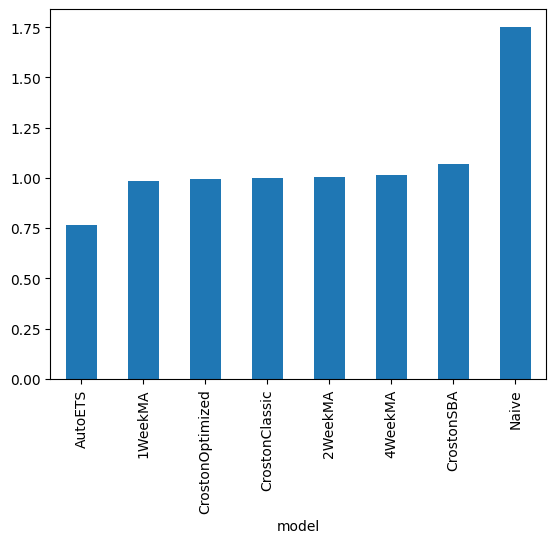

In [69]:
dfresults_stats.groupby("model")["wrmsse"].mean().sort_values().plot(kind="bar")

# LightGbm CV

Fit the above MLForecast with lgb.LGBMRegressor parameters `lgb_params` specified.

- FREQ: `D` daily
- LAG_FEATURES: Calculates a list of `n` period with (freq) lag (i.e. 1, 7 would be y_1 and y_7 equal to yesterday and today. 
- LAG_TRANSFORM_DICT: Specify dictionary of tranformations to apply against `LAG_FEATURES`

- `lgb_params`: parameter dictionary for lightgbm
    - `num_leaves` and `n_estimators` are the key ones handling regularization and complexity

In [ ]:
# Thread configuration - shared by MLForecast and LightGBM

NUM_THREADS = 4     # My testing showed this was optimal #TODO: Include optimization code 
                    # TLDR; ML TS Forecasting is often Memory bound, not CPU so cores was not helpful

lgb_params = {
    'verbose': 1,
    'num_threads': NUM_THREADS,  # Match MLForecast threading
    'force_col_wise': True,
    'num_leaves': 256,
    'n_estimators': 100,
}

N_WEEKLY_LAGS = 8
WEEKLY_LAG_FEATURES = [7 * (i+1) for i in range(8)]
LAG_FEATURES = [1, 2, 3, ] + WEEKLY_LAG_FEATURES

LAG_TRANSFORM_DICT = {
    1:  [ExpandingMean()],
    7:  [RollingMean(7), SeasonalRollingMean(7, 1)],    # Capture weekly trend ajusting for seasonality (day of week effects)
    14: [RollingMean(14), SeasonalRollingMean(14, 1)],  # Capture bi-weekly trend adjusting for seasonality (i.e. payday)
    28: [RollingMean(28), SeasonalRollingMean(28, 1)],  # Capture Monthly trend adjusting for monthly seasonality
}

# List of built-in date features to compute with MLForecast.date_features
DATE_FEATURE_LIST = [
        'year', 'month', 'day', 'day_of_week', 'quarter', 'week',
        'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
        is_first_or_fifteenth,
    ]

print(f"Configuration: MLForecast and LightGBM both using {NUM_THREADS} threads")

In [ ]:
%%time



fcst = MLForecast(
    models=[lgb.LGBMRegressor(**lgb_params)],
    freq='D',
    lags=LAG_FEATURES,
    lag_transforms = LAG_TRANSFORM_DICT,
    date_features = DATE_FEATURE_LIST,
    num_threads=NUM_THREADS,
)

PARAMS = fcst.models["LGBMRegressor"].get_params()

lgb_cv = fcst.cross_validation(h=HORIZON,
                               n_windows=1,
                               df=df,
                               static_features=id_cols,
                               id_col=id_col, time_col=time_col
                              )

## Combine CV Results

- `stat_cv` - DataFrame of stats models cross-validated predictions
- `lgb_cv` - DataFrame of lightgbm cross-validated predictions
- `df_cv` - DataFrame of combined cv results all forecasts

In [52]:
df_cv = stat_cv.merge(lgb_cv[[id_col, time_col, "cutoff", "LGBMRegressor"]],
                      on=[id_col, time_col, "cutoff"])
df_cv = df_cv.rename(columns={time_col: "ds"})

MODEL_NAMES = df_cv.drop(["id", "ds", "cutoff", "y"], axis="columns").columns.tolist()

df_cv[MODEL_NAMES] = df_cv[MODEL_NAMES].round(0)  # round forecast to nearest integer

cv_err = evaluate_cross_validation(df_cv, id_col=id_col,
                                   # metric=smape
                                   metric=mae
                                  )
cv_err["LGBMRegressor"] = cv_err["LGBMRegressor"].round(0)
bst = get_best_model_forecast(df_cv, cv_err, id_col)
assert int(bst.groupby("id", observed=True).agg({"best_model": "nunique"}).max().iloc[0]) == 1
bst.best_model.value_counts(normalize=True)

C:\Users\ricka\AppData\Local\Temp\ipykernel_22888\3772746967.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evals = evals.groupby(id_col).mean(numeric_only=True) # Averages the error metrics for all cutoffs for every combination of model and unique_id


best_model
LGBMRegressor       0.350377
Naive               0.318760
1WeekMA             0.144047
AutoETS             0.104920
2WeekMA             0.044408
4WeekMA             0.023844
CrostonClassic      0.009675
CrostonSBA          0.002919
CrostonOptimized    0.001050
Name: proportion, dtype: float64

# Fit LightGbm on Full Data

In [122]:
%%time

lgb_start_time = time.time()

last_date_train = df['date'].max()
last_wmyrwk = df[df['date'] < last_date_train]['wm_yr_wk'].max()
logger.info(f"""Begin fitting LightGbm with {df[id_col].nunique():,d} ids data before: {last_date_train.date()}""")

logger.info(f"""LGB Fit Parameters:\n{PARAMS}""")
fcst.fit(
    df,
    id_col=id_col,
    time_col=time_col,
    target_col='y',
    static_features=id_cols,
)

logger.info(f"""Finished fitting LightGbm on {df["id"].nunique():,d} time-series in {time.time()- lgb_start_time:,.2f} seconds.""")

2025-02-02 23:55:40.620 | INFO     | __main__:<module>:5 - Begin fitting LightGbm with 30,490 ids data before: 2016-05-22
2025-02-02 23:55:40.622 | INFO     | __main__:<module>:7 - LGB Fit Parameters:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 256, 'objective': None, 'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': 1, 'num_threads': 4, 'force_col_wise': True}


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 34831
[LightGBM] [Info] Number of data points in the train set: 45088780, number of used features: 45
[LightGBM] [Info] Start training from score 1.425767


2025-02-03 00:01:43.454 | INFO     | __main__:<module>:16 - Finished fitting LightGbm on 30,490 time-series in 367.57 seconds.


CPU times: user 20min 18s, sys: 18.2 s, total: 20min 36s
Wall time: 6min 7s


In [123]:
## Create Future Regressors

cal = load_calendar(PATH_INPUT)
prices = load_prices(PATH_INPUT)

X_df = create_future_features(last_date_train, cal, prices, HORIZON)
X_df = X_df.merge(cal[["date", "d", "wm_yr_wk"]], on='date', how='left')

2025-02-03 00:01:43.464 | DEBUG    | src.process:load_calendar:30 - Begin Loading Calendar Data...
2025-02-03 00:01:43.529 | DEBUG    | src.process:load_prices:44 - Begin Loading Price Data...


In [124]:
%%time
preds = fcst.predict(HORIZON, X_df=X_df)
logger.info(f"""Finished generating {HORIZON:,d} days of predictions for {preds["id"].nunique():,d} time-series in {time.time()- lgb_start_time:,.2f} seconds.""")

2025-02-03 00:01:56.288 | INFO     | __main__:<module>:2 - Finished generating 28 days of predictions for 30,490 time-series in 380.40 seconds.


CPU times: user 18.1 s, sys: 1.75 s, total: 19.9 s
Wall time: 8.85 s


In [158]:
TEST_START 

1942

# Create Submission

In [161]:
def make_submission(preds: pd.DataFrame,
                    h: int) -> pd.DataFrame:
    wide = preds.pivot_table(index='id',
                             columns='date',
                             observed=True)
    # wide.columns = [f'F{i+1}' for i in range(h)]
    wide.columns = [f'd_{TEST_START + i}' for i in range(h)]
    wide.columns.name = None
    wide.index.name = 'id'
    return wide

submission = make_submission(preds, HORIZON)
submission = submission.join(df[id_cols].set_index("id").drop_duplicates())
# submission.to_csv("data/ml_benchmark.csv")
submission.reset_index().rename(columns={"id": "unique_id"}).to_parquet("data/ml_baseline.snap.parquet")

In [162]:
submission

,d_1942,d_1943,d_1944,d_1945,d_1946,d_1947,d_1948,d_1949,d_1950,d_1951,...,d_1965,d_1966,d_1967,d_1968,d_1969,item_id,dept_id,cat_id,store_id,state_id
id,,,,,,,,,,,,,,,,,,,,,
FOODS_1_001_CA_1_evaluation,0.701140,0.858599,0.774327,0.817852,0.957635,1.233709,1.188126,0.838755,0.786562,0.774742,...,0.754253,0.748211,0.877114,1.103670,1.099405,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
FOODS_1_001_CA_2_evaluation,0.729126,0.799108,0.785350,0.818576,0.960839,1.197364,1.261475,0.782686,0.798074,0.869764,...,0.866279,0.898848,0.984810,1.247570,1.297708,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
FOODS_1_001_CA_3_evaluation,0.977203,0.877520,0.859335,0.831788,1.051413,1.175588,1.223946,0.906082,0.933188,1.033952,...,0.935167,0.929125,1.061426,1.269831,1.257585,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
FOODS_1_001_CA_4_evaluation,0.178846,0.228902,0.295045,0.320118,0.355710,0.395775,0.421469,0.330799,0.317200,0.364547,...,0.361051,0.380703,0.373739,0.402344,0.404603,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
FOODS_1_001_TX_1_evaluation,0.593642,0.905085,0.765304,0.800519,0.898751,1.040235,1.112625,0.813078,0.789266,0.742996,...,0.711239,0.697510,0.790894,0.983039,0.979863,FOODS_1_001,FOODS_1,FOODS,TX_1,TX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HOUSEHOLD_2_516_TX_2_evaluation,0.215575,0.242546,0.275643,0.275643,0.298782,0.358378,0.378982,0.281818,0.278832,0.288368,...,0.292560,0.292585,0.336693,0.395477,0.393225,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX
HOUSEHOLD_2_516_TX_3_evaluation,0.353509,0.314403,0.318199,0.290450,0.315385,0.353773,0.394723,0.339277,0.353372,0.364913,...,0.320801,0.325689,0.352665,0.398563,0.409801,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_3,TX
HOUSEHOLD_2_516_WI_1_evaluation,0.159356,0.181270,0.230615,0.263766,0.329102,0.368062,0.368062,0.266955,0.266955,0.276094,...,0.280683,0.280708,0.350078,0.411930,0.411933,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_1,WI


In [163]:
print(f"""Notebook finished in {(time.time() - start_time) / 60:.2f}m""")

Notebook finished in 214.08m
